---
title: "Robustness of YOLOv8 Under Image Degradations"
format:
    html: 
        code-fold: false
---

## Imports

In [21]:
import os
import glob
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import yaml
import pandas as pd
from pathlib import Path

## Degradation Pipeline

OpenCV with randomized parameter ranges

### Implementation

In [2]:
# Set random seed
np.random.seed(297)

# Apply blur
def apply_blur(img):
    k = np.random.choice([9, 11, 15])
    return cv2.GaussianBlur(img, (k, k), 0)

# Apply noise
def apply_noise(img):
    std = np.random.uniform(25, 40)
    noise = np.random.normal(0, std, img.shape).astype(np.float32)
    out = img.astype(np.float32) + noise
    return np.clip(out, 0, 255).astype(np.uint8)

# Apply motion blur
def apply_motion(img):
    k = np.random.choice([13, 15, 17])
    kernel = np.zeros((k, k), dtype=np.float32)
    # Choose direction
    direction = np.random.choice(["horizontal", "vertical", "diag_down", "diag_up"])
    if direction == "horizontal":
        kernel[k // 2, :] = 1.0
    elif direction == "vertical":
        kernel[:, k // 2] = 1.0
    elif direction == "diag_down":
        np.fill_diagonal(kernel, 1.0)
    else:
        np.fill_diagonal(np.fliplr(kernel), 1.0)
    kernel = kernel / kernel.sum()
    return cv2.filter2D(img, -1, kernel)

# Apply mixed degradation
def apply_mixed(img):
    out = apply_blur(img)
    out = apply_noise(out)
    out = apply_motion(out)
    return out

In [3]:
# Create degraded set
def make_degraded_set(src_img_dir, src_lbl_dir, out_img_dir, out_lbl_dir, mode):
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)
    image_paths = sorted(glob.glob(os.path.join(src_img_dir, "*.jpg")))
    image_paths += sorted(glob.glob(os.path.join(src_img_dir, "*.png")))
    image_paths += sorted(glob.glob(os.path.join(src_img_dir, "*.jpeg")))

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        stem = os.path.splitext(filename)[0]
        # Read image
        img = cv2.imread(img_path)
        if img is None:
            continue
        # Apply chosen degradation
        if mode == "blur":
            out = apply_blur(img)
        elif mode == "noise":
            out = apply_noise(img)
        elif mode == "motion":
            out = apply_motion(img)
        elif mode == "mixed":
            out = apply_mixed(img)
        else:
            raise ValueError("mode must be blur, noise, motion, or mixed")
        # Save degraded image
        cv2.imwrite(os.path.join(out_img_dir, filename), out)
        # Copy label
        label_src = os.path.join(src_lbl_dir, stem + ".txt")
        label_dst = os.path.join(out_lbl_dir, stem + ".txt")
        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)

In [4]:
# Set base path
base = "../data/processed/stage3_disease"

# Set source folders
src_img = os.path.join(base, "images", "test")
src_lbl = os.path.join(base, "labels", "test")
train_src_img = os.path.join(base, "images", "train")
train_src_lbl = os.path.join(base, "labels", "train")

# Create blur set
make_degraded_set(
    src_img, src_lbl,
    os.path.join(base, "images", "test_blur"),
    os.path.join(base, "labels", "test_blur"),
    "blur"
)

# Create noise set
make_degraded_set(
    src_img, src_lbl,
    os.path.join(base, "images", "test_noise"),
    os.path.join(base, "labels", "test_noise"),
    "noise"
)

# Create motion set
make_degraded_set(
    src_img, src_lbl,
    os.path.join(base, "images", "test_motion"),
    os.path.join(base, "labels", "test_motion"),
    "motion"
)

# Create mixed set
make_degraded_set(
    src_img, src_lbl,
    os.path.join(base, "images", "test_mixed"),
    os.path.join(base, "labels", "test_mixed"),
    "mixed"
)

# Create blur training set
make_degraded_set(
    train_src_img, train_src_lbl,
    os.path.join(base, "images", "train_blur"),
    os.path.join(base, "labels", "train_blur"),
    "blur"
)

# Create noise training set
make_degraded_set(
    train_src_img, train_src_lbl,
    os.path.join(base, "images", "train_noise"),
    os.path.join(base, "labels", "train_noise"),
    "noise"
)

# Create motion training set
make_degraded_set(
    train_src_img, train_src_lbl,
    os.path.join(base, "images", "train_motion"),
    os.path.join(base, "labels", "train_motion"),
    "motion"
)

# Create mixed training set
make_degraded_set(
    train_src_img, train_src_lbl,
    os.path.join(base, "images", "train_mixed"),
    os.path.join(base, "labels", "train_mixed"),
    "mixed"
)

In [5]:
# Check folder counts
for folder in ["test", "test_blur", "test_noise", "test_motion", "test_mixed", "train", "train_blur", "train_noise", "train_motion", "train_mixed"]:
    img_dir = os.path.join(base, "images", folder)
    lbl_dir = os.path.join(base, "labels", folder)

    print(folder)
    print("images:", len(os.listdir(img_dir)))
    print("labels:", len(os.listdir(lbl_dir)))
    print("-" * 30)

test
images: 250
labels: 250
------------------------------
test_blur
images: 250
labels: 250
------------------------------
test_noise
images: 250
labels: 250
------------------------------
test_motion
images: 250
labels: 250
------------------------------
test_mixed
images: 250
labels: 250
------------------------------
train
images: 705
labels: 705
------------------------------
train_blur
images: 705
labels: 705
------------------------------
train_noise
images: 705
labels: 705
------------------------------
train_motion
images: 705
labels: 705
------------------------------
train_mixed
images: 705
labels: 705
------------------------------


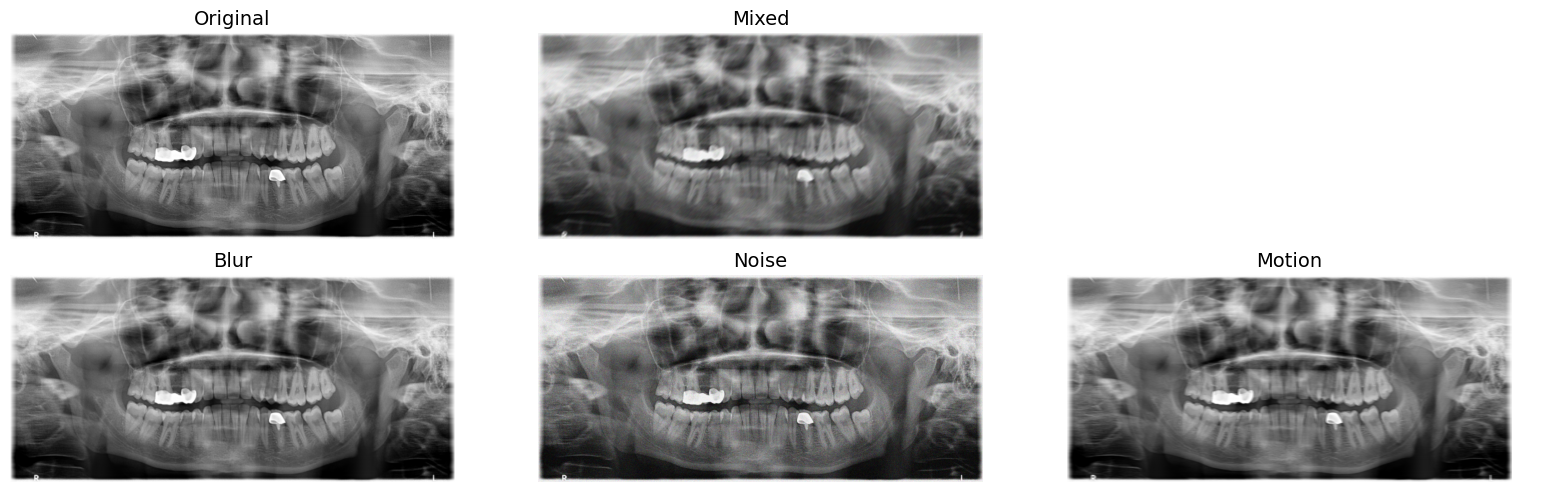

In [6]:
# Show results
img = cv2.imread("../data/processed/stage3_disease/images/test/test_0.png")
plt.figure(figsize=(16, 5))  

# Original
plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original", fontsize=14)
plt.axis("off")

# Mixed
plt.subplot(2,3,2)
plt.imshow(cv2.cvtColor(apply_mixed(img), cv2.COLOR_BGR2RGB))
plt.title("Mixed", fontsize=14)
plt.axis("off")

# Empty space 
plt.subplot(2,3,3)
plt.axis("off")

# Blur
plt.subplot(2,3,4)
plt.imshow(cv2.cvtColor(apply_blur(img), cv2.COLOR_BGR2RGB))
plt.title("Blur", fontsize=14)
plt.axis("off")

# Noise
plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(apply_noise(img), cv2.COLOR_BGR2RGB))
plt.title("Noise", fontsize=14)
plt.axis("off")

# Motion
plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(apply_motion(img), cv2.COLOR_BGR2RGB))
plt.title("Motion", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

### Combine clean + degraded train sets

In [7]:
# Create combined augmented train folders
train_aug_img_dir = os.path.join(base, "images", "train_aug")
train_aug_lbl_dir = os.path.join(base, "labels", "train_aug")

# Remove old folders if they already exist
if os.path.exists(train_aug_img_dir):
    shutil.rmtree(train_aug_img_dir)
if os.path.exists(train_aug_lbl_dir):
    shutil.rmtree(train_aug_lbl_dir)

# Create fresh folders
os.makedirs(train_aug_img_dir, exist_ok=True)
os.makedirs(train_aug_lbl_dir, exist_ok=True)

# Combine clean and degraded folders
train_folders = ["train", "train_blur", "train_noise", "train_motion", "train_mixed"]
for folder in train_folders:
    img_folder = os.path.join(base, "images", folder)
    lbl_folder = os.path.join(base, "labels", folder)
    image_paths = sorted(glob.glob(os.path.join(img_folder, "*.jpg")))
    image_paths += sorted(glob.glob(os.path.join(img_folder, "*.png")))
    image_paths += sorted(glob.glob(os.path.join(img_folder, "*.jpeg")))
    for img_path in image_paths:
        filename = os.path.basename(img_path)
        stem, ext = os.path.splitext(filename)
        # Add folder name so filenames do not overlap
        new_img_name = f"{stem}_{folder}{ext}"
        new_lbl_name = f"{stem}_{folder}.txt"
        shutil.copy(img_path, os.path.join(train_aug_img_dir, new_img_name))
        label_path = os.path.join(lbl_folder, stem + ".txt")
        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(train_aug_lbl_dir, new_lbl_name))

print("Augmented train images:", len(os.listdir(train_aug_img_dir)))
print("Augmented train labels:", len(os.listdir(train_aug_lbl_dir)))

Augmented train images: 3525
Augmented train labels: 3525


## Baseline YOLOv8 Model

In [10]:
# Load YOLOv8
model = YOLO("yolov8n.pt")

results = model.train(
    data="../data/processed/yamls/stage3_disease.yaml",  
    epochs=50,
    patience=10,
    imgsz=640,
    batch=16,
    name="stage3_baseline"
)

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/processed/yamls/stage3_disease.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage3_baseline-4, nbs=64, nms=False, opset=None, optimize=False, optimizer

### Load the trained model

In [11]:
# Load best baseline model
best_model = YOLO("runs/detect/stage3_baseline/weights/best.pt")

### Create YAMLs for each test condition

In [12]:
# Set base dataset path
base_path = "../data/processed/stage3_disease"

# Set class names
class_names = {
    0: "Impacted",
    1: "Caries",
    2: "Periapical_Lesion",
    3: "Deep_Caries"
}

# Build yaml maker
def save_test_yaml(filename, test_folder):
    data = {
        "path": base_path,
        "train": "images/train",
        "val": "images/val",
        "test": f"images/{test_folder}",
        "nc": 4,
        "names": class_names
    }
    
    # Save yaml
    with open(filename, "w") as f:
        yaml.dump(data, f, sort_keys=False)

In [13]:
# Save clean yaml
save_test_yaml("stage3_clean_test.yaml", "test")

# Save blur yaml
save_test_yaml("stage3_blur_test.yaml", "test_blur")

# Save noise yaml
save_test_yaml("stage3_noise_test.yaml", "test_noise")

# Save motion yaml
save_test_yaml("stage3_motion_test.yaml", "test_motion")

# Save mixed yaml
save_test_yaml("stage3_mixed_test.yaml", "test_mixed")

### Run evaluation on each test set

In [14]:
# Evaluate clean test
clean_metrics = best_model.val(data="stage3_clean_test.yaml", split="test")

# Evaluate blur test
blur_metrics = best_model.val(data="stage3_blur_test.yaml", split="test")

# Evaluate noise test
noise_metrics = best_model.val(data="stage3_noise_test.yaml", split="test")

# Evaluate motion test
motion_metrics = best_model.val(data="stage3_motion_test.yaml", split="test")

# Evaluate mixed test
mixed_metrics = best_model.val(data="stage3_mixed_test.yaml", split="test")

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1152.2651.1 MB/s, size: 4115.8 KB)
val: Scanning C:\GitHub Local\6600-dental-enumeration-and-condition\data\processed\stage3_disease\labels\test.cache... 250 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 8.4it/s 1.9s<0.1s
                   all        250       1469      0.378      0.431       0.36      0.232
              Impacted         91        221      0.857       0.91      0.938      0.588
                Caries        226        747      0.285      0.764      0.359      0.256
     Periapical_Lesion        112        236      0.351     0.0297      0.126      0.074
           Deep_Caries         81        265     0.0205     0.01

### Print the main results

In [15]:
# Print mAP50 results
print("Clean mAP50: ", clean_metrics.box.map50)
print("Blur mAP50:  ", blur_metrics.box.map50)
print("Noise mAP50: ", noise_metrics.box.map50)
print("Motion mAP50:", motion_metrics.box.map50)
print("Mixed mAP50: ", mixed_metrics.box.map50)

# Print mAP50-95 results
print("Clean mAP50-95: ", clean_metrics.box.map)
print("Blur mAP50-95:  ", blur_metrics.box.map)
print("Noise mAP50-95: ", noise_metrics.box.map)
print("Motion mAP50-95:", motion_metrics.box.map)
print("Mixed mAP50-95: ", mixed_metrics.box.map)

Clean mAP50:  0.3598747517795394
Blur mAP50:   0.3621958709998962
Noise mAP50:  0.0782152819983298
Motion mAP50: 0.3389601078109307
Mixed mAP50:  0.20037907826430978
Clean mAP50-95:  0.23234747409347295
Blur mAP50-95:   0.2332105624803876
Noise mAP50-95:  0.04210106412799788
Motion mAP50-95: 0.20615563760429234
Mixed mAP50-95:  0.10130254593136209


### Put results into a table

In [16]:
# Build results table
results_table = pd.DataFrame({
    "Condition": ["Clean", "Blur", "Noise", "Motion", "Mixed"],
    "mAP50": [
        clean_metrics.box.map50,
        blur_metrics.box.map50,
        noise_metrics.box.map50,
        motion_metrics.box.map50,
        mixed_metrics.box.map50
    ],
    "mAP50-95": [
        clean_metrics.box.map,
        blur_metrics.box.map,
        noise_metrics.box.map,
        motion_metrics.box.map,
        mixed_metrics.box.map
    ]
})

# Show table
results_table

,Condition,mAP50,mAP50-95
0,Clean,0.359875,0.232347
1,Blur,0.362196,0.233211
2,Noise,0.078215,0.042101
3,Motion,0.338960,0.206156
4,Mixed,0.200379,0.101303


### Calculate performance drop

In [17]:
# Store clean reference
clean_map50 = clean_metrics.box.map50

# Add drop column
results_table["mAP50 Drop"] = clean_map50 - results_table["mAP50"]

# Show updated table
results_table

,Condition,mAP50,mAP50-95,mAP50 Drop
0,Clean,0.359875,0.232347,0.000000
1,Blur,0.362196,0.233211,-0.002321
2,Noise,0.078215,0.042101,0.281659
3,Motion,0.338960,0.206156,0.020915
4,Mixed,0.200379,0.101303,0.159496


## Augmented YOLOv8

### Create augmented training YAML

In [19]:
# Create YAML for augmented training
aug_train_yaml = {
    "path": base,
    "train": "images/train_aug",
    "val": "images/val",
    "test": "images/test",
    "nc": 4,
    "names": class_names
}

# Save YAML file
aug_train_yaml_path = "stage3_aug_train.yaml"
with open(aug_train_yaml_path, "w") as f:
    yaml.dump(aug_train_yaml, f, sort_keys=False)

### Train augmented YOLOv8

In [20]:
# Load YOLOv8 model
aug_train_model = YOLO("yolov8n.pt")

# Train with clean + degraded training images
aug_train_results = aug_train_model.train(
    data=aug_train_yaml_path,
    epochs=50,
    patience=10,
    imgsz=640,
    batch=16,
    name="stage3_augmented"
)

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=stage3_aug_train.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage3_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

### Load augmented model

In [24]:
# Get the saved training folder
aug_save_dir = Path(aug_train_model.trainer.save_dir)

# Load best augmented model
aug_model = YOLO(str(aug_save_dir / "weights" / "best.pt"))

### Evaluate augmented model

In [25]:
aug_clean_metrics = aug_model.val(data="stage3_clean_test.yaml", split="test")
aug_blur_metrics = aug_model.val(data="stage3_blur_test.yaml", split="test")
aug_noise_metrics = aug_model.val(data="stage3_noise_test.yaml", split="test")
aug_motion_metrics = aug_model.val(data="stage3_motion_test.yaml", split="test")
aug_mixed_metrics = aug_model.val(data="stage3_mixed_test.yaml", split="test")

Ultralytics 8.4.41  Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1261.3253.9 MB/s, size: 4646.7 KB)
val: Scanning C:\GitHub Local\6600-dental-enumeration-and-condition\data\processed\stage3_disease\labels\test.cache... 250 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 7.6it/s 2.1s<0.1s
                   all        250       1469      0.395      0.467      0.376      0.239
              Impacted         91        221      0.826      0.955       0.94      0.575
                Caries        226        747      0.272      0.788      0.373      0.271
     Periapical_Lesion        112        236      0.464      0.106      0.171     0.0995
           Deep_Caries         81        265     0.0177     0.01

### Build Comparison Table

In [26]:
# Build augmented results table
aug_results_table = pd.DataFrame({
    "Condition": ["Clean", "Blur", "Noise", "Motion", "Mixed"],
    "Aug_mAP50": [
        aug_clean_metrics.box.map50,
        aug_blur_metrics.box.map50,
        aug_noise_metrics.box.map50,
        aug_motion_metrics.box.map50,
        aug_mixed_metrics.box.map50
    ],
    "Aug_mAP50-95": [
        aug_clean_metrics.box.map,
        aug_blur_metrics.box.map,
        aug_noise_metrics.box.map,
        aug_motion_metrics.box.map,
        aug_mixed_metrics.box.map
    ]
})

# Rename baseline columns
baseline_table = results_table.rename(columns={
    "mAP50": "Baseline_mAP50",
    "mAP50-95": "Baseline_mAP50-95",
    "mAP50 Drop": "Baseline_mAP50_Drop"
})

# Merge tables
comparison_table = baseline_table.merge(
    aug_results_table,
    on="Condition",
    how="left"
)

# Calculate improvement
comparison_table["Aug_mAP50_Improvement"] = (
    comparison_table["Aug_mAP50"] - comparison_table["Baseline_mAP50"]
)

comparison_table["Aug_mAP50-95_Improvement"] = (
    comparison_table["Aug_mAP50-95"] - comparison_table["Baseline_mAP50-95"]
)

comparison_table

,Condition,Baseline_mAP50,Baseline_mAP50-95,Baseline_mAP50_Drop,Aug_mAP50,Aug_mAP50-95,Aug_mAP50_Improvement,Aug_mAP50-95_Improvement
0,Clean,0.359875,0.232347,0.000000,0.375621,0.239432,0.015746,0.007084
1,Blur,0.362196,0.233211,-0.002321,0.379888,0.240787,0.017693,0.007577
2,Noise,0.078215,0.042101,0.281659,0.365241,0.222847,0.287026,0.180746
3,Motion,0.338960,0.206156,0.020915,0.374244,0.233677,0.035284,0.027521
4,Mixed,0.200379,0.101303,0.159496,0.373138,0.229844,0.172759,0.128541
